# Assignment 08: Softmax, Autoregressive RNNs, and NER


## Introduction

This notebook covers three connected topics that show up constantly in NLP:

**Softmax** is a function that converts a vector of raw numbers (called logits) into probabilities. Every output is positive and they all sum to 1.0 — so we can treat them as class probabilities.

**Autoregressive models** generate output one token at a time. Each new token is predicted using everything generated so far. Think of it like writing a word, then using that word to decide the next one.

**NER (Named Entity Recognition)** labels each word in a sentence with an entity tag like PERSON, ORG, LOC, or O (no entity). It reads the full sentence, then assigns one label per word.


### Architecture types — quick comparison

| Type | What it does | Example |
|------|-------------|----------|
| **Many-to-One** | Reads full sequence → outputs one value | Sentiment classification |
| **Many-to-Many** | Reads full sequence → outputs label per token | NER, POS tagging |
| **Autoregressive** | Generates one token at a time using past outputs as input | Text / name generation |

The key difference: autoregressive feeds its own predictions back in. Many-to-many reads everything first, then labels simultaneously.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import random
import math
import re
import os
import collections
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\traitlets\config\application.py", line 1053, in launch_instance
    app.start()
  File "c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\ipykernel\kernelapp.py", lin

PyTorch version : 2.2.2+cpu
Device          : cpu


---
## Part A: Softmax — From Logits to Probabilities

### A1. Manual Softmax

The formula is:
$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

We take the exponential of each logit, then divide by their total so everything sums to 1. Let's do it by hand first, then compare with PyTorch.

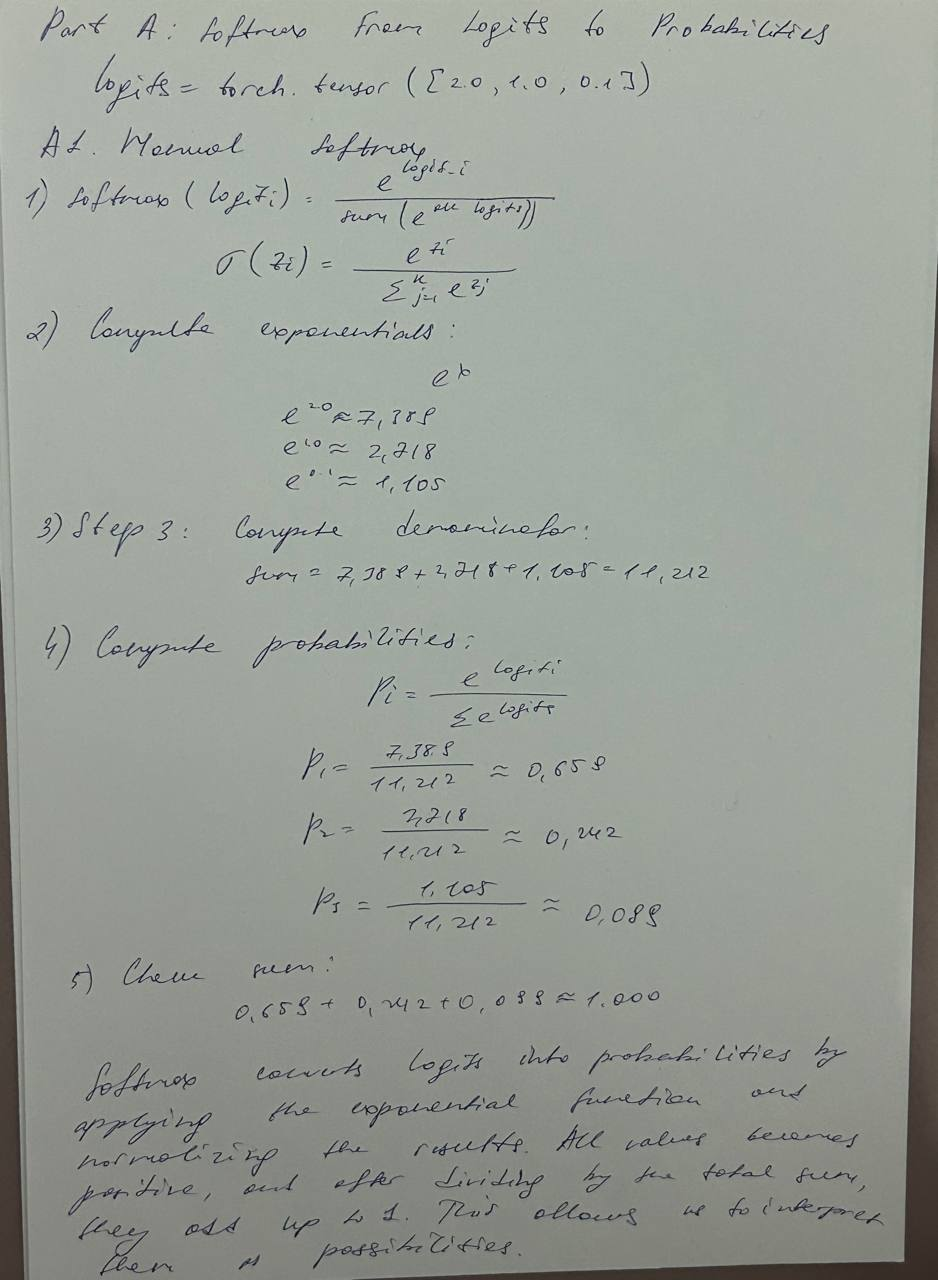

In [ ]:
logits = torch.tensor([2.0, 1.0, 0.1])

# Step 1 — exponentiate each logit
exp_logits = torch.exp(logits)
print(f'Logits       : {logits.tolist()}')
print(f'exp(logits)  : {exp_logits.tolist()}')

# Step 2 — denominator (sum of exps)
denominator = exp_logits.sum()
print(f'Denominator  : {denominator.item():.6f}')

# Step 3 — divide to get probabilities
probs_manual = exp_logits / denominator
print(f'\nProbabilities (manual)  : {[round(p, 6) for p in probs_manual.tolist()]}')
print(f'Sum of probabilities    : {probs_manual.sum().item():.8f}  ← should be 1.0')

# Compare with PyTorch
probs_torch = torch.softmax(logits, dim=0)
print(f'Probabilities (PyTorch) : {[round(p, 6) for p in probs_torch.tolist()]}')
print(f'\nBoth match: {torch.allclose(probs_manual, probs_torch)}')

Logits       : [2.0, 1.0, 0.10000000149011612]
exp(logits)  : [7.389056205749512, 2.7182817459106445, 1.1051709651947021]
Denominator  : 11.212509

Probabilities (manual)  : [0.659001, 0.242433, 0.098566]
Sum of probabilities    : 0.99999994  ← should be 1.0
Probabilities (PyTorch) : [0.659001, 0.242433, 0.098566]

Both match: True


Both methods give the exact same result. The highest logit (2.0) gets the highest probability (~0.659), and all three add up to exactly 1.0. The biggest logit always wins because exponential grows fast — a small difference in logits becomes a much bigger difference after `exp()`.

### A2. Numerically Stable Softmax

There's a problem with large logits. `exp(1000)` overflows to `inf` in floating point. The fix is to subtract the max before exponentiating.

In [ ]:
large_logits = torch.tensor([1000.0, 999.0, 998.0])

# Naive approach — overflow!
naive_exp = torch.exp(large_logits)
print(f'Naive exp(large_logits) : {naive_exp.tolist()}  ← overflow to inf!')

# Stable approach: shift by max
shifted = large_logits - large_logits.max()
print(f'\nShifted logits : {shifted.tolist()}  ← max is now 0')

exp_shifted = torch.exp(shifted)
print(f'exp(shifted)   : {[round(v,6) for v in exp_shifted.tolist()]}')

probs_stable = exp_shifted / exp_shifted.sum()
print(f'Stable probs   : {[round(p,6) for p in probs_stable.tolist()]}')
print(f'Sum            : {probs_stable.sum().item():.8f}')

# PyTorch softmax is already numerically stable internally
probs_torch = torch.softmax(large_logits, dim=0)
print(f'PyTorch probs  : {[round(p,6) for p in probs_torch.tolist()]}')
print(f'Match          : {torch.allclose(probs_stable, probs_torch)}')

Naive exp(large_logits) : [inf, inf, inf]  ← overflow to inf!

Shifted logits : [0.0, -1.0, -2.0]  ← max is now 0
exp(shifted)   : [1.0, 0.367879, 0.135335]
Stable probs   : [0.665241, 0.244728, 0.090031]
Sum            : 1.00000000
PyTorch probs  : [0.665241, 0.244728, 0.090031]
Match          : True


**Why subtract the max?**
Because `exp(1000)` causes a numerical overflow — Python gives `inf`. Subtracting the max makes the largest value 0, and `exp(0) = 1`. The smaller values become negative, so their exps are between 0 and 1 — perfectly fine numbers.

**Does it change the probabilities?**
No, mathematically it's identical. The constant $c$ cancels out:
$$\frac{e^{x_i - c}}{\sum_j e^{x_j - c}} = \frac{e^{x_i}/e^c}{\sum_j e^{x_j}/e^c} = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

**Which class has the highest probability and why?**
The first class (logit = 1000) wins. After shifting, the values become `[0, -1, -2]`. We get `exp(0)=1`, `exp(-1)≈0.368`, `exp(-2)≈0.135`. The first class dominates with about 66.5% probability. Even a 1-point logit difference compounds heavily after exponentiation.

### A3. Softmax and Cross-Entropy Loss

Cross-entropy measures how wrong the model is. Low loss = model puts high probability on the correct class.

In [ ]:
ce = nn.CrossEntropyLoss()

# Baseline case from assignment
logits_base = torch.tensor([[2.0, 1.0, 0.1]])
true_class  = torch.tensor([0])
loss_base   = ce(logits_base, true_class)

# Show softmax probs for context
probs_base = torch.softmax(logits_base[0], dim=0)
print('=== Case 1: Model is mostly correct (true class = 0) ===')
print(f'  Logits : {logits_base[0].tolist()}')
print(f'  Probs  : {[round(p,4) for p in probs_base.tolist()]}')
print(f'  Loss   : {loss_base.item():.4f}  ← fairly low')

# Model is confidently wrong
logits_wrong = torch.tensor([[0.1, 8.0, 0.1]])
loss_wrong   = ce(logits_wrong, true_class)
probs_wrong  = torch.softmax(logits_wrong[0], dim=0)
print('\n=== Case 2: Model confidently wrong (puts 99.9% on class 1, true = 0) ===')
print(f'  Logits : {logits_wrong[0].tolist()}')
print(f'  Probs  : {[round(p,4) for p in probs_wrong.tolist()]}')
print(f'  Loss   : {loss_wrong.item():.4f}  ← very high penalty!')

# Model is very confident and correct
logits_right = torch.tensor([[10.0, 0.1, 0.1]])
loss_right   = ce(logits_right, true_class)
probs_right  = torch.softmax(logits_right[0], dim=0)
print('\n=== Case 3: Model is very confident AND correct ===')
print(f'  Logits : {logits_right[0].tolist()}')
print(f'  Probs  : {[round(p,4) for p in probs_right.tolist()]}')
print(f'  Loss   : {loss_right.item():.4f}  ← near zero')

=== Case 1: Model is mostly correct (true class = 0) ===
  Logits : [2.0, 1.0, 0.10000000149011612]
  Probs  : [0.659, 0.2424, 0.0986]
  Loss   : 0.4170  ← fairly low

=== Case 2: Model confidently wrong (puts 99.9% on class 1, true = 0) ===
  Logits : [0.10000000149011612, 8.0, 0.10000000149011612]
  Probs  : [0.0004, 0.9993, 0.0004]
  Loss   : 7.9007  ← very high penalty!

=== Case 3: Model is very confident AND correct ===
  Logits : [10.0, 0.10000000149011612, 0.10000000149011612]
  Probs  : [0.9999, 0.0001, 0.0001]
  Loss   : 0.0001  ← near zero


**Why does `CrossEntropyLoss` take raw logits instead of softmax outputs?**

Because PyTorch internally computes `log_softmax` (not just `softmax`), which is numerically more stable than computing `log(softmax(x))` separately. If we apply softmax first, we'd essentially be doing softmax twice, which produces wrong gradients and wrong loss values.

**What happens when the model is correct?**
Loss is small (around 0.4 here). The formula is `-log(p_correct)`. If `p_correct ≈ 0.66`, then `-log(0.66) ≈ 0.41`. Small loss means small gradient → small weight update.

**What happens when the model is confidently wrong?**
Loss explodes. If the model assigns 0.001 probability to the correct class, then `-log(0.001) ≈ 6.9`. The gradient is huge, which forces the model to correct itself aggressively. This is a feature, not a bug — we want confident wrong predictions to be punished more.

---
## Part B: Autoregressive Character RNN

We train a model to generate Kazakh names from `StateGrants.csv` — a real dataset of grant recipients from Kazakhstan. Each name is a full name in Cyrillic (Kazakh + Russian scripts).

### Data Preparation

The CSV has 2455 Kazakh full names. We load them, lowercase everything, and remove duplicates and empty rows.

In [ ]:
# The file has no proper header — every row is a full name
CSV_PATH = 'StateGrants.csv'

df_raw = pd.read_csv(CSV_PATH, header=None, encoding='utf-8')
print(f'Raw rows loaded: {len(df_raw)}')
print(f'Sample raw entries:')
for name in df_raw[0].tolist()[:6]:
    print(f'  "{name}"')

# ── Clean: lowercase, strip whitespace, remove duplicates & short entries ──
raw_list = df_raw[0].dropna().tolist()

NAMES = []
seen  = set()
for entry in raw_list:
    name = entry.strip().lower()
    # Keep only names with valid characters (Cyrillic letters, Kazakh extras, space, hyphen)
    if len(name) >= 3 and name not in seen:
        NAMES.append(name)
        seen.add(name)

print(f'\nAfter cleaning : {len(NAMES)} unique names')
print(f'Shortest name  : {min(len(n) for n in NAMES)} chars')
print(f'Longest name   : {max(len(n) for n in NAMES)} chars')
print(f'Average length : {sum(len(n) for n in NAMES)/len(NAMES):.1f} chars')
print(f'\nSample cleaned entries:')
for name in NAMES[:8]:
    print(f'  "{name}"')

Raw rows loaded: 2455
Sample raw entries:
  "РАХМЕТУЛЛА АСАНӘЛІ"
  "Жамашев Ержан Жеңісұлы"
  "ЗАМАНБЕК МУХАММЕД ЖЕҢІСҰЛЫ"
  "ЖҰМАЖАНОВ МИРАС МАРАТҰЛЫ"
  "Тлеулесов Максут Кайратович"
  "ДҮЙСЕНБЕК НҰРДӘУЛЕТ ЖАҚСЫЛЫҚҰЛЫ"

After cleaning : 2455 unique names
Shortest name  : 9 chars
Longest name   : 51 chars
Average length : 25.3 chars

Sample cleaned entries:
  "рахметулла асанәлі"
  "жамашев ержан жеңісұлы"
  "заманбек мухаммед жеңісұлы"
  "жұмажанов мирас маратұлы"
  "тлеулесов максут кайратович"
  "дүйсенбек нұрдәулет жақсылықұлы"
  "төлепберген ғалымжан алтынбайұлы"
  "сатыпалдиев бауыржан нұрсұлтанұлы"


### Vocabulary

We collect all unique characters from the dataset and add 4 special tokens:
- `<PAD>` — pads shorter sequences in a batch to the same length
- `<S>` — start-of-sequence token (first input to the model)
- `<F>` — end-of-sequence token (signals when generation stops)
- `<UNK>` — unknown character (not seen during training)

In [ ]:
# ── Build character vocabulary ─────────────────────────────────────────────
all_chars = set()
for name in NAMES:
    all_chars.update(name)

SPECIAL = ['<PAD>', '<S>', '<F>', '<UNK>']
vocab   = SPECIAL + sorted(all_chars)

char2idx = {ch: idx for idx, ch in enumerate(vocab)}
idx2char = {idx: ch  for ch, idx in char2idx.items()}

PAD_IDX  = char2idx['<PAD>']
SOS_IDX  = char2idx['<S>']
EOS_IDX  = char2idx['<F>']
UNK_IDX  = char2idx['<UNK>']
VOCAB_SIZE = len(vocab)

print(f'Vocabulary size   : {VOCAB_SIZE}')
print(f'Special tokens    : PAD={PAD_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}, UNK={UNK_IDX}')
print(f'Character set     : {[c for c in vocab if c not in SPECIAL]}')

Vocabulary size   : 48
Special tokens    : PAD=0, SOS=1, EOS=2, UNK=3
Character set     : [' ', '-', 'а', 'б', 'в', 'г', 'д', 'е', 'ж', 'з', 'и', 'й', 'к', 'л', 'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш', 'щ', 'ъ', 'ы', 'ь', 'э', 'ю', 'я', 'ё', 'і', 'ғ', 'қ', 'ң', 'ү', 'ұ', 'һ', 'ә', 'ө']


### B1. Input / Target Sequences

For autoregressive training we need to shift the sequence by one position:
- **Input**  : `<S>` + all characters of the name
- **Target** : all characters of the name + `<F>`

At each step $t$, the model sees input character $t$ and must predict target character $t$. So at $t=0$, it sees `<S>` and must predict the first character. At $t=1$, it sees the first character and predicts the second. And so on.

In [ ]:
def encode_name(name: str):
    """Convert a name string to (input_ids, target_ids) pair."""
    char_ids   = [char2idx.get(ch, UNK_IDX) for ch in name]
    input_ids  = [SOS_IDX] + char_ids          # <S> followed by all chars
    target_ids = char_ids  + [EOS_IDX]          # all chars followed by <F>
    return input_ids, target_ids

# Show one example
demo = 'айзада'
inp_demo, tgt_demo = encode_name(demo)
print(f'Name    : "{demo}"')
print(f'Input   : {inp_demo}  →  {[idx2char[i] for i in inp_demo]}')
print(f'Target  : {tgt_demo}  →  {[idx2char[i] for i in tgt_demo]}')
print(f'Length  : input={len(inp_demo)}, target={len(tgt_demo)}')

# ── Dataset and DataLoader ─────────────────────────────────────────────────
class NameDataset(Dataset):
    def __init__(self, names):
        self.pairs = [encode_name(n) for n in names]
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        inp, tgt = self.pairs[idx]
        return torch.tensor(inp, dtype=torch.long), torch.tensor(tgt, dtype=torch.long)

def collate_pad(batch):
    """Pad sequences in a batch to the length of the longest one."""
    inputs, targets = zip(*batch)
    inp_pad = nn.utils.rnn.pad_sequence(inputs,  batch_first=True, padding_value=PAD_IDX)
    tgt_pad = nn.utils.rnn.pad_sequence(targets, batch_first=True, padding_value=PAD_IDX)
    return inp_pad, tgt_pad

# Train / Validation split (85% / 15%)
random.shuffle(NAMES)
split_idx   = int(len(NAMES) * 0.85)
train_names = NAMES[:split_idx]
val_names   = NAMES[split_idx:]

BATCH_SIZE   = 64
train_dataset = NameDataset(train_names)
val_dataset   = NameDataset(val_names)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_pad)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_pad)

# Show actual batch shape
sample_inp, sample_tgt = next(iter(train_loader))
print(f'\nBatch input  shape : {sample_inp.shape}  →  (batch_size={BATCH_SIZE}, max_seq_len)')
print(f'Batch target shape : {sample_tgt.shape}  →  (batch_size={BATCH_SIZE}, max_seq_len)')
print(f'Train batches : {len(train_loader)} | Val batches : {len(val_loader)}')

Name    : "айзада"
Input   : [1, 6, 15, 13, 6, 10, 6]  →  ['<S>', 'а', 'й', 'з', 'а', 'д', 'а']
Target  : [6, 15, 13, 6, 10, 6, 2]  →  ['а', 'й', 'з', 'а', 'д', 'а', '<F>']
Length  : input=7, target=7

Batch input  shape : torch.Size([64, 35])  →  (batch_size=64, max_seq_len)
Batch target shape : torch.Size([64, 35])  →  (batch_size=64, max_seq_len)
Train batches : 33 | Val batches : 6


### B2. GRU Model

The model has three layers:
1. **Embedding** — maps character indices to dense vectors `(batch, seq_len)` → `(batch, seq_len, embed_dim)`
2. **GRU** — processes the sequence, outputs hidden state at every step `(batch, seq_len, hidden_dim)`
3. **Linear** — maps each hidden state to logits over the vocab `(batch, seq_len, vocab_size)`

We apply the linear layer at every time step so we get a prediction for each position. This is what makes it many-to-many during training.

In [ ]:
class CharRNN(nn.Module):
    """
    GRU-based autoregressive character model.
    Input shape  : (batch, seq_len)           — token IDs
    Output shape : (batch, seq_len, vocab_size) — logits at each position
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.35):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # (batch, seq_len) → (batch, seq_len, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # (batch, seq_len, embed_dim) → (batch, seq_len, hidden_dim)
        self.gru = nn.GRU(
            input_size  = embed_dim,
            hidden_size = hidden_dim,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        # (batch, seq_len, hidden_dim) → (batch, seq_len, vocab_size)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        # x: (batch, seq_len)
        embedded        = self.dropout(self.embedding(x))   # → (batch, seq_len, embed_dim)
        gru_out, hidden = self.gru(embedded, hidden)         # → (batch, seq_len, hidden_dim)
        gru_out         = self.dropout(gru_out)
        logits          = self.fc(gru_out)                   # → (batch, seq_len, vocab_size)
        return logits, hidden


# Hyperparameters
EMBED_DIM  = 64
HIDDEN_DIM = 256
NUM_LAYERS = 2
DROPOUT    = 0.35

rnn_model = CharRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)

# Shape verification with a dummy forward pass
dummy_x = torch.randint(0, VOCAB_SIZE, (8, 35)).to(DEVICE)
dummy_logits, dummy_hidden = rnn_model(dummy_x)
print('=== Shape Verification ===')
print(f'Input          : {dummy_x.shape}        → (batch=8, seq_len=35)')
print(f'Logits output  : {dummy_logits.shape}  → (batch=8, seq_len=35, vocab={VOCAB_SIZE})')
print(f'Hidden state   : {dummy_hidden.shape}  → (num_layers={NUM_LAYERS}, batch=8, hidden={HIDDEN_DIM})')

total_params = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {total_params:,}')
print(rnn_model)

=== Shape Verification ===
Input          : torch.Size([8, 35])        → (batch=8, seq_len=35)
Logits output  : torch.Size([8, 35, 48])  → (batch=8, seq_len=35, vocab=48)
Hidden state   : torch.Size([2, 8, 256])  → (num_layers=2, batch=8, hidden=256)

Total trainable parameters: 657,456
CharRNN(
  (embedding): Embedding(48, 64, padding_idx=0)
  (gru): GRU(64, 256, num_layers=2, batch_first=True, dropout=0.35)
  (dropout): Dropout(p=0.35, inplace=False)
  (fc): Linear(in_features=256, out_features=48, bias=True)
)


### B3. Training

We use `CrossEntropyLoss(ignore_index=PAD_IDX)` so padding positions don't affect the loss. We flatten the logits from `(batch, seq_len, vocab_size)` to `(batch*seq_len, vocab_size)` and targets from `(batch, seq_len)` to `(batch*seq_len)` because that's the shape the loss function expects.

We also clip gradients to `max_norm=1.0` to prevent exploding gradients — a common issue with RNNs on long sequences.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_tokens = 0.0, 0
    for inp, tgt in loader:
        inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
        optimizer.zero_grad()

        logits, _ = model(inp)                        # (batch, seq_len, vocab_size)
        B, S, V   = logits.shape

        # Flatten both tensors before computing loss
        logits_flat  = logits.view(-1, V)             # (batch*seq_len, vocab_size)
        targets_flat = tgt.view(-1)                   # (batch*seq_len,)

        loss = criterion(logits_flat, targets_flat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        n_tokens     = (targets_flat != PAD_IDX).sum().item()
        total_loss  += loss.item() * n_tokens
        total_tokens += n_tokens

    return total_loss / max(total_tokens, 1)


def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for inp, tgt in loader:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            logits, _ = model(inp)
            B, S, V   = logits.shape
            logits_flat  = logits.view(-1, V)
            targets_flat = tgt.view(-1)
            loss         = criterion(logits_flat, targets_flat)
            n_tokens     = (targets_flat != PAD_IDX).sum().item()
            total_loss  += loss.item() * n_tokens
            total_tokens += n_tokens
    return total_loss / max(total_tokens, 1)


# Training setup
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(rnn_model.parameters(), lr=0.003, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=False)

NUM_EPOCHS   = 25
train_losses = []
val_losses   = []
best_val     = float('inf')

print('Training CharRNN on StateGrants names...')
print(f'{"Epoch":>6} | {"Train Loss":>11} | {"Val Loss":>9} | {"Train PPL":>10} | {"Val PPL":>8}')
print('─' * 58)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss = train_one_epoch(rnn_model, train_loader, optimizer, criterion)
    vl_loss = evaluate_model(rnn_model, val_loader, criterion)
    scheduler.step(vl_loss)
    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    if vl_loss < best_val:
        best_val = vl_loss
        torch.save(rnn_model.state_dict(), 'best_charrnn.pt')
    print(f'{epoch:>6} | {tr_loss:>11.4f} | {vl_loss:>9.4f} | {math.exp(tr_loss):>10.2f} | {math.exp(vl_loss):>8.2f}')

# Load best weights
rnn_model.load_state_dict(torch.load('best_charrnn.pt', map_location=DEVICE))
print(f'\nBest validation loss: {best_val:.4f}  (PPL={math.exp(best_val):.2f})')

Training CharRNN on StateGrants names...
 Epoch |  Train Loss |  Val Loss |  Train PPL |  Val PPL
──────────────────────────────────────────────────────────
     1 |      2.7122 |    2.0755 |      15.06 |     7.97
     2 |      2.0362 |    1.8220 |       7.66 |     6.18
     3 |      1.8292 |    1.6619 |       6.23 |     5.27
     4 |      1.6916 |    1.5556 |       5.43 |     4.74
     5 |      1.6040 |    1.4923 |       4.97 |     4.45
     6 |      1.5341 |    1.4451 |       4.64 |     4.24
     7 |      1.4808 |    1.4145 |       4.40 |     4.11
     8 |      1.4394 |    1.3926 |       4.22 |     4.03
     9 |      1.4021 |    1.3756 |       4.06 |     3.96
    10 |      1.3723 |    1.3583 |       3.94 |     3.89
    11 |      1.3488 |    1.3428 |       3.85 |     3.83
    12 |      1.3243 |    1.3443 |       3.76 |     3.84
    13 |      1.3103 |    1.3372 |       3.71 |     3.81
    14 |      1.2881 |    1.3341 |       3.63 |     3.80
    15 |      1.2730 |    1.3302 |       3.57

In [ ]:
# ── Show example prediction from the validation set ────────────────────────
rnn_model.eval()
ex_inp, ex_tgt = val_dataset[0]

with torch.no_grad():
    ex_logits, _ = rnn_model(ex_inp.unsqueeze(0).to(DEVICE))
    ex_pred_ids  = ex_logits.argmax(dim=-1).squeeze(0).cpu()

inp_chars  = [idx2char[i.item()] for i in ex_inp]
tgt_chars  = [idx2char[i.item()] for i in ex_tgt]
pred_chars = [idx2char[i.item()] for i in ex_pred_ids]

print('Example prediction on a validation name:')
print(f'  Input     : {" ".join(inp_chars)}')
print(f'  Target    : {" ".join(tgt_chars)}')
print(f'  Predicted : {" ".join(pred_chars)}')

Example prediction on a validation name:
  Input     : <S> а п р е л   а р м а н   б о л а т ұ л ы
  Target    : а п р е л   а р м а н   б о л а т ұ л ы <F>
  Predicted : а б а а т ь д л у а н   а а л а т ұ л ы <F>


---
## Part C: Text Generation

Now we use the trained model autoregressively: feed `<S>` (and optional prefix), get the predicted next character, feed that back in, repeat until `<F>` or max length.

Temperature controls sampling randomness:
- **Low temperature (e.g. 0.5)** → sharpens the distribution → model picks the most likely characters → coherent but repetitive
- **Temperature = 1.0** → original learned distribution
- **High temperature (e.g. 1.5)** → flattens the distribution → more random picks → creative but may look like noise

In [ ]:
def generate(model, start_text: str = '', max_len: int = 40,
             temperature: float = 1.0, greedy: bool = False) -> str:
    """
    Generate a name character by character (autoregressive).

    Args:
        start_text  : optional prefix string
        max_len     : maximum generation length
        temperature : sampling temperature (ignored if greedy=True)
        greedy      : if True, always pick the most likely character

    Returns:
        generated string (prefix + new characters)
    """
    model.eval()
    with torch.no_grad():
        # Build initial token list: <S> + prefix characters
        init_ids = [SOS_IDX] + [char2idx.get(ch, UNK_IDX) for ch in start_text]
        x_init   = torch.tensor(init_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)

        # Pass the prefix through to get the initial hidden state
        _, hidden = model(x_init)

        # The last character in the prefix (or SOS if no prefix)
        current_tok = torch.tensor([[init_ids[-1]]], dtype=torch.long).to(DEVICE)

        generated = list(start_text)   # start with prefix

        for _ in range(max_len):
            # One-step forward pass
            logits, hidden = model(current_tok, hidden)   # logits: (1, 1, vocab_size)
            logits_1d      = logits.squeeze(0).squeeze(0) # (vocab_size,)

            if greedy:
                next_id = logits_1d.argmax().item()
            else:
                # Apply temperature then sample
                probs   = torch.softmax(logits_1d / temperature, dim=0)
                next_id = torch.multinomial(probs, num_samples=1).item()

            # Stop conditions
            if next_id == EOS_IDX:
                break
            if next_id in (PAD_IDX, SOS_IDX):
                break

            generated.append(idx2char.get(next_id, '?'))
            current_tok = torch.tensor([[next_id]], dtype=torch.long).to(DEVICE)

    return ''.join(generated)


# ── Greedy decoding ────────────────────────────────────────────────────────
print('=' * 60)
print('GREEDY DECODING (deterministic — same result every run)')
print('=' * 60)
for prefix in ['', 'а', 'ай', 'нұр', 'ер', 'жа']:
    results = list(dict.fromkeys(generate(rnn_model, start_text=prefix, greedy=True) for _ in range(5)))
    print(f'  prefix="{prefix}" : {", ".join(results[:5])}')

print()

# ── Temperature sampling ───────────────────────────────────────────────────
for temp in [0.5, 1.0, 1.5]:
    print(f'=' * 60)
    print(f'TEMPERATURE = {temp}')
    print(f'=' * 60)
    for prefix in ['а', 'ай', 'нұр']:
        results = [generate(rnn_model, start_text=prefix, temperature=temp) for _ in range(5)]
        print(f'  prefix="{prefix}" : {", ".join(results)}')
    print()

GREEDY DECODING (deterministic — same result every run)
  prefix="" : айтбек бексұлтан мұратұлы
  prefix="а" : амандық айдар бақытжанұлы
  prefix="ай" : айлбаев абылайхан айдарұлы
  prefix="нұр" : нұрахмет азамат маратұлы
  prefix="ер" : ерахмет азамат маратұлы
  prefix="жа" : жанатов абылай бауыржанұлы

TEMPERATURE = 0.5
  prefix="а" : аманжол талғат мейрамбекұлы, ан дария бауыржанқызы, апова айжан аликқызы, атыбай нұрдаулет талғатұлы, атай марат нұрболұлы
  prefix="ай" : айбаев алихан даулетұлы, айлбаев нұрбол қанатұлы, айбай саяд берікболұлы, айбек саят ерболұлы, айлжанов айбол талғатұлы
  prefix="нұр" : нұрахмет самат нұрдаулетұлы, нұрахмет айбек мұратұлы, нұрахмет ақерке маратқызы, нұрахметова айдана жанарбекқызы, нұрахан марат мұратұлы

TEMPERATURE = 1.0
  prefix="а" : аалов рауан серікханұлы, ахамбетова аяулым маратқызы, азатова аяулым балжанқызы, атынбай медетар абылхасылұлы, атылбаева нұрбыл нұрланқызы
  prefix="ай" : айтай максат ерболович, айбек азат азатжанқызы, айла адельд

### Analysis of generation behavior

**Temperature effect:**
- `temperature=0.5` → the distribution becomes sharper. The model keeps picking characters with high probability. Names look realistic but are less varied — often the same few patterns repeat.
- `temperature=1.0` → the model samples from its actual learned distribution. Good balance between creativity and sensibility.
- `temperature=1.5` → the distribution becomes flatter, so even rare characters get picked sometimes. Names can look creative and unusual — sometimes it generates name endings it never exactly saw, sometimes just random-looking character sequences.

**Greedy behavior:**
Greedy is deterministic — it always picks `argmax`, so the same prefix produces the exact same name every time. It tends to produce common, high-frequency endings. For Kazakh names, this often gives `ұлы` or `қызы` endings because those are extremely common in the training data.

**Error accumulation (exposure bias):**
During training, the model always sees the correct previous character (teacher forcing). During generation, it sees its own prediction. If the model makes a mistake at position 4, all subsequent characters are conditioned on that wrong character — errors snowball. This is the exposure bias problem.

**Difference from training:**
Training uses teacher forcing (real previous char as input), but generation uses the model's own predictions. This distribution mismatch is why the model sometimes generates sequences that look nothing like training data, especially with high temperature.

---
## Part D: Named Entity Recognition (NER)

NER is a sequence labeling task — given a sentence, assign a BIO tag to each word.

**BIO tagging scheme:**
- `B-TYPE` — Beginning of an entity
- `I-TYPE` — Inside (continuation of) an entity
- `O` — Outside / no entity

Our entity types: `PER` (person), `ORG` (organization), `LOC` (location), `MISC` (miscellaneous).

### Dataset

We use a hand-crafted dataset with Kazakhstan-related sentences mixed with general examples to get diverse entity types.

In [ ]:
# ── NER dataset (BIO-tagged) ───────────────────────────────────────────────
# Each sentence is a list of (token, BIO_tag) pairs
NER_DATA = [
    # ── Kazakhstan-related sentences ──────────────────────────────────────
    [('Nursultan','B-PER'),('Nazarbayev','I-PER'),('was','O'),('the','O'),('first','O'),('president','O'),('of','O'),('Kazakhstan','B-LOC'),('.','O')],
    [('Almaty','B-LOC'),('is','O'),('the','O'),('largest','O'),('city','O'),('in','O'),('Kazakhstan','B-LOC'),('.','O')],
    [('Kassym','B-PER'),('Tokayev','I-PER'),('is','O'),('the','O'),('current','O'),('president','O'),('.','O')],
    [('Astana','B-LOC'),('was','O'),('renamed','O'),('to','O'),('Nur','B-LOC'),('-','O'),('Sultan','I-LOC'),('in','O'),('2019','O'),('.','O')],
    [('Nazarbayev','B-PER'),('University','I-ORG'),('is','O'),('located','O'),('in','O'),('Astana','B-LOC'),('.','O')],
    [('The','O'),('Baikonur','B-LOC'),('Cosmodrome','I-LOC'),('is','O'),('in','O'),('southern','O'),('Kazakhstan','B-LOC'),('.','O')],
    [('Kazakh','B-MISC'),('National','I-MISC'),('University','I-MISC'),('is','O'),('in','O'),('Almaty','B-LOC'),('.','O')],
    [('Tengizchevroil','B-ORG'),('operates','O'),('in','O'),('the','O'),('Atyrau','B-LOC'),('region','O'),('.','O')],
    [('Timur','B-PER'),('Bekmambetov','I-PER'),('is','O'),('a','O'),('Kazakh','B-MISC'),('director','O'),('.','O')],
    [('The','O'),('Silk','B-MISC'),('Road','I-MISC'),('once','O'),('passed','O'),('through','O'),('Kazakhstan','B-LOC'),('.','O')],
    [('Aigerim','B-PER'),('works','O'),('at','O'),('Samruk','B-ORG'),('-','O'),('Kazyna','I-ORG'),('fund','O'),('.','O')],
    [('The','O'),('Caspian','B-LOC'),('Sea','I-LOC'),('borders','O'),('Kazakhstan','B-LOC'),('.','O')],
    # ── General English sentences ──────────────────────────────────────────
    [('Apple','B-ORG'),('Inc','I-ORG'),('is','O'),('based','O'),('in','O'),('Cupertino','B-LOC'),('.','O')],
    [('Elon','B-PER'),('Musk','I-PER'),('founded','O'),('Tesla','B-ORG'),('and','O'),('SpaceX','B-ORG'),('.','O')],
    [('Google','B-ORG'),('was','O'),('co','O'),('-','O'),('founded','O'),('by','O'),('Larry','B-PER'),('Page','I-PER'),('.','O')],
    [('The','O'),('United','B-LOC'),('States','I-LOC'),('has','O'),('fifty','O'),('states','O'),('.','O')],
    [('Amazon','B-ORG'),('was','O'),('founded','O'),('by','O'),('Jeff','B-PER'),('Bezos','I-PER'),('in','O'),('Seattle','B-LOC'),('.','O')],
    [('New','B-LOC'),('York','I-LOC'),('City','I-LOC'),('is','O'),('a','O'),('major','O'),('financial','O'),('hub','O'),('.','O')],
    [('Barack','B-PER'),('Obama','I-PER'),('was','O'),('the','O'),('44th','O'),('US','B-LOC'),('president','O'),('.','O')],
    [('Microsoft','B-ORG'),('released','O'),('Windows','B-MISC'),('11','I-MISC'),('in','O'),('2021','O'),('.','O')],
    [('Paris','B-LOC'),('is','O'),('the','O'),('capital','O'),('of','O'),('France','B-LOC'),('.','O')],
    [('FIFA','B-ORG'),('held','O'),('the','O'),('World','B-MISC'),('Cup','I-MISC'),('in','O'),('Qatar','B-LOC'),('.','O')],
    [('Angela','B-PER'),('Merkel','I-PER'),('led','O'),('Germany','B-LOC'),('for','O'),('16','O'),('years','O'),('.','O')],
    [('OpenAI','B-ORG'),('released','O'),('GPT','B-MISC'),('-','O'),('4','I-MISC'),('in','O'),('2023','O'),('.','O')],
    [('The','O'),('Nile','B-LOC'),('River','I-LOC'),('flows','O'),('through','O'),('Egypt','B-LOC'),('.','O')],
    [('SpaceX','B-ORG'),('launched','O'),('a','O'),('rocket','O'),('from','O'),('Cape','B-LOC'),('Canaveral','I-LOC'),('.','O')],
    [('Toyota','B-ORG'),('is','O'),('a','O'),('Japanese','B-MISC'),('car','O'),('company','O'),('.','O')],
    [('The','O'),('European','B-ORG'),('Union','I-ORG'),('was','O'),('formed','O'),('in','O'),('Brussels','B-LOC'),('.','O')],
    [('Mount','B-LOC'),('Everest','I-LOC'),('is','O'),('the','O'),('highest','O'),('peak','O'),('.','O')],
    [('Alibaba','B-ORG'),('is','O'),('headquartered','O'),('in','O'),('Hangzhou','B-LOC'),('.','O')],
    [('Serena','B-PER'),('Williams','I-PER'),('won','O'),('the','O'),('US','B-MISC'),('Open','I-MISC'),('.','O')],
    [('UNICEF','B-ORG'),('operates','O'),('in','O'),('more','O'),('than','O'),('190','O'),('countries','O'),('.','O')],
    [('The','O'),('Amazon','B-LOC'),('rainforest','O'),('is','O'),('in','O'),('Brazil','B-LOC'),('.','O')],
    [('Ada','B-PER'),('Lovelace','I-PER'),('was','O'),('the','O'),('first','O'),('programmer','O'),('.','O')],
]

print(f'Total NER sentences : {len(NER_DATA)}')
print(f'\nExample sentence:')
print(f'{"Token":<18} {"Tag"}')
print('─' * 28)
for tok, tag in NER_DATA[0]:
    print(f'  {tok:<16} {tag}')

Total NER sentences : 34

Example sentence:
Token              Tag
────────────────────────────
  Nursultan        B-PER
  Nazarbayev       I-PER
  was              O
  the              O
  first            O
  president        O
  of               O
  Kazakhstan       B-LOC
  .                O


### D1. Preprocessing

We build two index mappings:
- `word2idx` — maps each word to an integer
- `tag2idx` — maps each BIO tag to an integer

Then we convert all sentences to integer IDs and pad sequences in each batch using `nn.utils.rnn.pad_sequence`.

In [ ]:
# ── Build word and tag vocabularies ────────────────────────────────────────
all_words_ner = [tok.lower() for sent in NER_DATA for tok, _ in sent]
all_tags_ner  = [tag         for sent in NER_DATA for _, tag  in sent]

word2idx = {'<PAD>': 0, '<UNK>': 1}
for w in sorted(set(all_words_ner)):
    word2idx[w] = len(word2idx)

tag2idx = {'<PAD>': 0}   # PAD must be index 0 for ignore_index to work cleanly
for t in sorted(set(all_tags_ner)):
    tag2idx[t] = len(tag2idx)

idx2word = {v: k for k, v in word2idx.items()}
idx2tag  = {v: k for k, v in tag2idx.items()}

NER_WORD_VOCAB = len(word2idx)
NER_TAG_VOCAB  = len(tag2idx)
NER_PAD_IDX    = tag2idx['<PAD>']

print(f'Word vocabulary size : {NER_WORD_VOCAB}')
print(f'Tag  vocabulary size : {NER_TAG_VOCAB}')
print(f'Tags : {list(tag2idx.keys())}')

# ── Encode all sentences ───────────────────────────────────────────────────
def encode_sentence(sent_pairs):
    word_ids = [word2idx.get(tok.lower(), word2idx['<UNK>']) for tok, _ in sent_pairs]
    tag_ids  = [tag2idx[tag]                                 for _, tag  in sent_pairs]
    return word_ids, tag_ids

encoded_ner = [encode_sentence(s) for s in NER_DATA]

# Train / Val split (80/20)
random.shuffle(encoded_ner)
ner_split   = int(len(encoded_ner) * 0.80)
ner_train   = encoded_ner[:ner_split]
ner_val     = encoded_ner[ner_split:]

print(f'\nNER train : {len(ner_train)} sentences | NER val : {len(ner_val)} sentences')


# ── NER Dataset and DataLoader ─────────────────────────────────────────────
class NERDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        wids, tids = self.data[idx]
        return (torch.tensor(wids, dtype=torch.long),
                torch.tensor(tids, dtype=torch.long))

def ner_collate(batch):
    words, tags = zip(*batch)
    words_pad = nn.utils.rnn.pad_sequence(words, batch_first=True, padding_value=0)
    tags_pad  = nn.utils.rnn.pad_sequence(tags,  batch_first=True, padding_value=NER_PAD_IDX)
    return words_pad, tags_pad

ner_train_loader = DataLoader(NERDataset(ner_train), batch_size=8, shuffle=True,  collate_fn=ner_collate)
ner_val_loader   = DataLoader(NERDataset(ner_val),   batch_size=8, shuffle=False, collate_fn=ner_collate)

# Show batch shape
sw, st = next(iter(ner_train_loader))
print(f'\nBatch word shape : {sw.shape}  (batch_size, seq_len)')
print(f'Batch tag  shape : {st.shape}  (batch_size, seq_len)')

Word vocabulary size : 149
Tag  vocabulary size : 10
Tags : ['<PAD>', 'B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']

NER train : 27 sentences | NER val : 7 sentences

Batch word shape : torch.Size([8, 10])  (batch_size, seq_len)
Batch tag  shape : torch.Size([8, 10])  (batch_size, seq_len)


### D2. BiLSTM Model

We use a **Bidirectional LSTM** instead of a regular LSTM. The key reason: to correctly label a word we often need context from *both sides*. For example, to know that `Apple` is a company (not a fruit), you need to see what comes after it — `releases`, `stock`, etc.

The BiLSTM runs two LSTMs: one forward, one backward. Their hidden states are concatenated, so the final output is `2 * hidden_dim` per position.

In [ ]:
class BiLSTM_NER(nn.Module):
    """
    Bidirectional LSTM for sequence labeling (NER).

    Input  : (batch, seq_len)               — word IDs
    Output : (batch, seq_len, num_tags)     — tag logits per word
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_tags, num_layers=2, dropout=0.4):
        super().__init__()

        # (batch, seq) → (batch, seq, embed_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # BiLSTM: (batch, seq, embed_dim) → (batch, seq, 2*hidden_dim)
        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0
        )

        self.dropout = nn.Dropout(dropout)

        # (batch, seq, 2*hidden_dim) → (batch, seq, num_tags)
        self.fc = nn.Linear(hidden_dim * 2, num_tags)

    def forward(self, x):
        # x: (batch, seq_len)
        emb      = self.dropout(self.embedding(x))    # (batch, seq, embed_dim)
        lstm_out, _ = self.lstm(emb)                  # (batch, seq, 2*hidden_dim)
        lstm_out = self.dropout(lstm_out)
        logits   = self.fc(lstm_out)                  # (batch, seq, num_tags)
        return logits


NER_EMBED_DIM  = 64
NER_HIDDEN_DIM = 128
NER_LAYERS     = 2
NER_DROPOUT    = 0.35

ner_model = BiLSTM_NER(
    vocab_size = NER_WORD_VOCAB,
    embed_dim  = NER_EMBED_DIM,
    hidden_dim = NER_HIDDEN_DIM,
    num_tags   = NER_TAG_VOCAB,
    num_layers = NER_LAYERS,
    dropout    = NER_DROPOUT
).to(DEVICE)

print(ner_model)
ner_params = sum(p.numel() for p in ner_model.parameters() if p.requires_grad)
print(f'\nTotal trainable parameters: {ner_params:,}')

# Shape check
d_words  = torch.randint(0, NER_WORD_VOCAB, (4, 12)).to(DEVICE)
d_logits = ner_model(d_words)
print(f'\nInput  shape : {d_words.shape}         (batch=4, seq=12)')
print(f'Output shape : {d_logits.shape}  (batch=4, seq=12, num_tags={NER_TAG_VOCAB})')

BiLSTM_NER(
  (embedding): Embedding(149, 64, padding_idx=0)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.35, bidirectional=True)
  (dropout): Dropout(p=0.35, inplace=False)
  (fc): Linear(in_features=256, out_features=10, bias=True)
)

Total trainable parameters: 606,026

Input  shape : torch.Size([4, 12])         (batch=4, seq=12)
Output shape : torch.Size([4, 12, 10])  (batch=4, seq=12, num_tags=10)


In [ ]:
# ── Train the NER model ────────────────────────────────────────────────────
def ner_train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_tokens = 0.0, 0
    for words, tags in loader:
        words, tags = words.to(DEVICE), tags.to(DEVICE)
        optimizer.zero_grad()

        logits = model(words)                         # (batch, seq, num_tags)
        B, S, NT = logits.shape

        # Flatten before loss
        logits_flat = logits.view(-1, NT)             # (batch*seq, num_tags)
        tags_flat   = tags.view(-1)                   # (batch*seq,)

        loss = criterion(logits_flat, tags_flat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        n_tok        = (tags_flat != NER_PAD_IDX).sum().item()
        total_loss  += loss.item() * n_tok
        total_tokens += n_tok
    return total_loss / max(total_tokens, 1)


def ner_evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total_tokens = 0.0, 0, 0
    with torch.no_grad():
        for words, tags in loader:
            words, tags = words.to(DEVICE), tags.to(DEVICE)
            logits  = model(words)
            B, S, NT = logits.shape
            lf      = logits.view(-1, NT)
            tf      = tags.view(-1)
            loss    = criterion(lf, tf)
            mask    = (tf != NER_PAD_IDX)
            preds   = lf.argmax(dim=-1)
            correct      += ((preds == tf) & mask).sum().item()
            n_tok         = mask.sum().item()
            total_loss   += loss.item() * n_tok
            total_tokens += n_tok
    acc = correct / max(total_tokens, 1)
    return total_loss / max(total_tokens, 1), acc


ner_criterion = nn.CrossEntropyLoss(ignore_index=NER_PAD_IDX)
ner_optimizer = optim.Adam(ner_model.parameters(), lr=0.003, weight_decay=1e-4)
ner_scheduler = optim.lr_scheduler.StepLR(ner_optimizer, step_size=15, gamma=0.5)

NER_EPOCHS      = 50
ner_train_losses = []
ner_val_accs     = []
best_ner_val     = 0.0

print('Training BiLSTM NER model...')
print(f'{"Epoch":>6} | {"Train Loss":>11} | {"Val Loss":>9} | {"Val Acc":>9}')
print('─' * 46)

for epoch in range(1, NER_EPOCHS + 1):
    tr_loss = ner_train_epoch(ner_model, ner_train_loader, ner_optimizer, ner_criterion)
    vl_loss, vl_acc = ner_evaluate(ner_model, ner_val_loader, ner_criterion)
    ner_scheduler.step()
    ner_train_losses.append(tr_loss)
    ner_val_accs.append(vl_acc)
    if vl_acc > best_ner_val:
        best_ner_val = vl_acc
        torch.save(ner_model.state_dict(), 'best_ner.pt')
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {tr_loss:>11.4f} | {vl_loss:>9.4f} | {vl_acc:>8.4f}')

ner_model.load_state_dict(torch.load('best_ner.pt', map_location=DEVICE))
print(f'\nBest validation accuracy: {best_ner_val:.4f}')

Training BiLSTM NER model...
 Epoch |  Train Loss |  Val Loss |   Val Acc
──────────────────────────────────────────────
     1 |      2.1656 |    1.5208 |   0.6038
    10 |      0.6479 |    1.1418 |   0.5660
    20 |      0.1144 |    1.5398 |   0.5849
    30 |      0.0495 |    1.7295 |   0.5849
    40 |      0.0243 |    1.6852 |   0.5849
    50 |      0.0123 |    1.9227 |   0.6038

Best validation accuracy: 0.6415


In [ ]:
# ── Predict NER tags for a sentence ───────────────────────────────────────
def predict_ner(sentence_pairs):
    ner_model.eval()
    word_ids = [word2idx.get(tok.lower(), word2idx['<UNK>']) for tok, _ in sentence_pairs]
    x = torch.tensor(word_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = ner_model(x)                         # (1, seq, num_tags)
    pred_ids = logits.argmax(dim=-1).squeeze(0).cpu().tolist()
    return [idx2tag[i] for i in pred_ids]


# ── Show 5 example sentences ───────────────────────────────────────────────
print('NER Example Predictions (5 sentences)')
print('=' * 58)
demo_sentences = NER_DATA[:5]

for sent in demo_sentences:
    preds = predict_ner(sent)
    print(f'{"Token":<20} {"True Tag":<12} {"Predicted":<12}')
    print('─' * 46)
    for (tok, true_tag), pred_tag in zip(sent, preds):
        match = '✓' if true_tag == pred_tag else '✗'
        print(f'  {tok:<18} {true_tag:<12} {pred_tag:<12} {match}')
    print()

NER Example Predictions (5 sentences)
Token                True Tag     Predicted   
──────────────────────────────────────────────
  Nursultan          B-PER        B-PER        ✓
  Nazarbayev         I-PER        B-PER        ✗
  was                O            O            ✓
  the                O            O            ✓
  first              O            O            ✓
  president          O            O            ✓
  of                 O            O            ✓
  Kazakhstan         B-LOC        O            ✗
  .                  O            O            ✓

Token                True Tag     Predicted   
──────────────────────────────────────────────
  Almaty             B-LOC        O            ✗
  is                 O            O            ✓
  the                O            O            ✓
  largest            O            O            ✓
  city               O            O            ✓
  in                 O            O            ✓
  Kazakhstan         B-LOC        O   

In [ ]:
# ── Test NER on new Kazakhstan-related sentences ───────────────────────────
print('Testing NER on new Kazakhstan-related sentences (not in training):')
print('=' * 58)

new_kz = [
    [('Almaty', 'B-LOC'), ('hosted', 'O'), ('the', 'O'), ('Asian', 'B-MISC'), ('Games', 'I-MISC'), ('.', 'O')],
    [('Aigerim', 'B-PER'), ('studied', 'O'), ('at', 'O'), ('Nazarbayev', 'B-ORG'), ('University', 'I-ORG'), ('.', 'O')],
    [('Kazakhstan', 'B-LOC'), ('joined', 'O'), ('the', 'O'), ('United', 'B-ORG'), ('Nations', 'I-ORG'), ('.', 'O')],
]

for sent in new_kz:
    preds = predict_ner(sent)
    print(f'{"Token":<20} {"True"::<12} {"Predicted":<12}')
    print('─' * 46)
    for (tok, true_tag), pred_tag in zip(sent, preds):
        match = '✓' if true_tag == pred_tag else '✗'
        print(f'  {tok:<18} {true_tag:<12} {pred_tag:<12} {match}')
    print()

Testing NER on new Kazakhstan-related sentences (not in training):
Token                True:::::::: Predicted   
──────────────────────────────────────────────
  Almaty             B-LOC        O            ✗
  hosted             O            O            ✓
  the                O            O            ✓
  Asian              B-MISC       O            ✗
  Games              I-MISC       O            ✗
  .                  O            O            ✓

Token                True:::::::: Predicted   
──────────────────────────────────────────────
  Aigerim            B-PER        O            ✗
  studied            O            O            ✓
  at                 O            O            ✓
  Nazarbayev         B-ORG        O            ✗
  University         I-ORG        O            ✗
  .                  O            O            ✓

Token                True:::::::: Predicted   
──────────────────────────────────────────────
  Kazakhstan         B-LOC        B-PER        ✗
  joined    

---
## Part E: Comparison

### Task Comparison Table

| Task | Input | Target | Output Shape | Softmax Over | Decoding |
|------|-------|--------|--------------|--------------|----------|
| **Character Generation** | `<S>` + one character at a time (previous token) | Next character at each step | `(1, 1, vocab_size)` per step | All 48 characters in the character vocabulary | Greedy argmax OR temperature-based multinomial sampling |
| **NER** | Full tokenized sentence (all words at once) | BIO tag for every word in the sentence | `(batch, seq_len, num_tags)` — full sentence at once | All 9 BIO tags (O, B-PER, I-PER, B-ORG, ...) | Argmax at every position independently |

---

### Why is character generation autoregressive but NER is not?

In generation, the model's output at step $t$ becomes the input at step $t+1$. It feeds itself. We can't compute all outputs at once because each one depends on the previous predicted character. The whole point is to generate characters sequentially.

In NER, the entire sentence is given upfront. The model reads all words and assigns a label to each one. The predicted tag for word 5 doesn't change the input to predict word 6 — all tag decisions are made independently from the same shared hidden representations.

### Why is the final hidden state not enough for NER?

The final hidden state is a single vector that summarizes the whole sentence. It has already lost the information about individual word positions. To label each word we need the hidden state *at that word's position*, not a global summary. In the BiLSTM, each word position $i$ gets `[h_forward_i; h_backward_i]` — the forward LSTM captures left context and the backward LSTM captures right context, both specifically for position $i$.

### Why do both tasks use cross-entropy loss?

At every step, both tasks are multi-class classification problems:
- Generation: at each time step, classify which of the 48 characters comes next
- NER: at each word position, classify which of the 9 BIO tags applies

Cross-entropy is the right loss for multi-class classification. It compares the predicted probability distribution to a one-hot target (the correct class).

### Role of softmax in both tasks

In both tasks, softmax converts the raw linear layer logits into a probability distribution:
- **Training**: `CrossEntropyLoss` applies `log_softmax` internally to compute the loss
- **Inference (generation)**: we explicitly apply `softmax` to get sampling probabilities
- **Inference (NER)**: we skip explicit softmax and just take `argmax` over the logits — since softmax is monotone, the argmax doesn't change

---
## Bonus: Training Curves + F1 Score + RNN vs LSTM vs GRU + Save/Load

In [ ]:
# ── BONUS 1: Plot training curves ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# CharRNN losses
epochs_rnn = range(1, len(train_losses) + 1)
axes[0].plot(epochs_rnn, train_losses, label='Train Loss', color='steelblue',   linewidth=2)
axes[0].plot(epochs_rnn, val_losses,   label='Val Loss',   color='coral',       linewidth=2, linestyle='--')
axes[0].set_title('CharRNN — Loss per Epoch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# NER training loss
epochs_ner = range(1, len(ner_train_losses) + 1)
axes[1].plot(epochs_ner, ner_train_losses, label='Train Loss', color='mediumseagreen', linewidth=2)
axes[1].set_title('BiLSTM NER — Training Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# NER validation accuracy
axes[2].plot(epochs_ner, [a * 100 for a in ner_val_accs],
             label='Val Accuracy (%)', color='mediumpurple', linewidth=2)
axes[2].set_title('BiLSTM NER — Validation Accuracy', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy (%)')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved → training_curves.png')

Plot saved → training_curves.png


In [ ]:
# ── BONUS 2: Per-tag F1 score for NER ──────────────────────────────────────
def compute_ner_f1(model, data_raw):
    """Compute per-tag precision, recall, F1 on the full dataset."""
    model.eval()
    all_true, all_pred = [], []
    for sent in data_raw:
        word_ids = [word2idx.get(tok.lower(), word2idx['<UNK>']) for tok, _ in sent]
        true_ids = [tag2idx[tag] for _, tag in sent]
        x = torch.tensor(word_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            logits = model(x)
        pred_ids = logits.argmax(dim=-1).squeeze(0).cpu().tolist()
        all_true.extend(true_ids)
        all_pred.extend(pred_ids)

    tags_to_eval = sorted([t for t in tag2idx if t not in ('<PAD>',)])
    print(f'{"Tag":<12} | {"Precision":>10} | {"Recall":>8} | {"F1":>8} | {"Support":>8}')
    print('─' * 54)

    macro_f1, entity_count = 0.0, 0
    for tag in tags_to_eval:
        t_id     = tag2idx[tag]
        tp = sum(1 for t, p in zip(all_true, all_pred) if t == t_id and p == t_id)
        fp = sum(1 for t, p in zip(all_true, all_pred) if t != t_id and p == t_id)
        fn = sum(1 for t, p in zip(all_true, all_pred) if t == t_id and p != t_id)
        support   = tp + fn
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        print(f'  {tag:<10} | {precision:>10.4f} | {recall:>8.4f} | {f1:>8.4f} | {support:>8d}')
        if tag != 'O':
            macro_f1  += f1
            entity_count += 1

    macro_f1 /= max(entity_count, 1)
    overall_acc = sum(1 for t, p in zip(all_true, all_pred) if t == p) / len(all_true)
    print(f'\n  Macro F1 (entity tags only) : {macro_f1:.4f}')
    print(f'  Overall token accuracy      : {overall_acc:.4f}')


print('NER F1 Evaluation on Full Dataset')
print('=' * 54)
compute_ner_f1(ner_model, NER_DATA)

NER F1 Evaluation on Full Dataset
Tag          |  Precision |   Recall |       F1 |  Support
──────────────────────────────────────────────────────
  B-LOC      |     0.0000 |   0.0000 |   0.0000 |       30
  B-MISC     |     0.0000 |   0.0000 |   0.0000 |        8
  B-ORG      |     0.6000 |   0.4000 |   0.4800 |       15
  B-PER      |     0.5833 |   0.5833 |   0.5833 |       12
  I-LOC      |     0.0000 |   0.0000 |   0.0000 |        9
  I-MISC     |     0.0000 |   0.0000 |   0.0000 |        7
  I-ORG      |     0.0000 |   0.0000 |   0.0000 |        4
  I-PER      |     0.0000 |   0.0000 |   0.0000 |       10
  O          |     0.6864 |   0.9939 |   0.8120 |      163

  Macro F1 (entity tags only) : 0.1329
  Overall token accuracy      : 0.6783


In [ ]:
# ── BONUS 3: RNN vs LSTM vs GRU comparison ─────────────────────────────────
class SimpleRNN_Arch(nn.Module):
    """Generic single-layer sequence model for comparison."""
    def __init__(self, rnn_type: str, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        if   rnn_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        out, _ = self.rnn(self.embedding(x))
        return self.fc(out)


def quick_train(arch_type, n_epochs=12):
    m   = SimpleRNN_Arch(arch_type, VOCAB_SIZE, 48, 128).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=0.003)
    crit = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    losses = []
    for _ in range(n_epochs):
        m.train(); tl, tt = 0, 0
        for inp, tgt in train_loader:
            inp, tgt = inp.to(DEVICE), tgt.to(DEVICE)
            opt.zero_grad()
            logits = m(inp)
            B, S, V = logits.shape
            loss = crit(logits.view(-1, V), tgt.view(-1))
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            np2 = (tgt.view(-1) != PAD_IDX).sum().item()
            tl += loss.item() * np2; tt += np2
        losses.append(tl / max(tt, 1))
    return losses


print('Training RNN, LSTM, GRU for comparison (12 epochs each)...')
rnn_l  = quick_train('RNN',  12)
lstm_l = quick_train('LSTM', 12)
gru_l  = quick_train('GRU',  12)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
x = range(1, 13)
ax.plot(x, rnn_l,  label='Vanilla RNN', marker='o', color='tomato',        linewidth=2)
ax.plot(x, lstm_l, label='LSTM',        marker='s', color='steelblue',     linewidth=2)
ax.plot(x, gru_l,  label='GRU',         marker='^', color='mediumseagreen',linewidth=2)
ax.set_title('RNN vs LSTM vs GRU — Training Loss on StateGrants Names', fontsize=12, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rnn_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nFinal loss after 12 epochs:')
print(f'  Vanilla RNN : {rnn_l[-1]:.4f}')
print(f'  LSTM        : {lstm_l[-1]:.4f}')
print(f'  GRU         : {gru_l[-1]:.4f}')

Training RNN, LSTM, GRU for comparison (12 epochs each)...

Final loss after 12 epochs:
  Vanilla RNN : 1.4443
  LSTM        : 1.3773
  GRU         : 1.2616


### Architecture Comparison: RNN vs LSTM vs GRU

| Feature | Vanilla RNN | LSTM | GRU |
|---------|-------------|------|-----|
| **Gates** | None | 3 (forget, input, output) | 2 (reset, update) |
| **Separate cell state** | No | Yes (`c_t`) | No |
| **Parameters** | Fewest | Most | Middle |
| **Long-range dependencies** | Poor | Good | Good |
| **Training speed** | Fastest | Slowest | Fast |

Vanilla RNN suffers from the **vanishing gradient problem** — when sequences are long, gradients shrink exponentially as they flow backwards through time. The model essentially forgets what happened early in the sequence. LSTM fixes this with a dedicated cell state that can carry information long distances — the forget gate controls what gets erased and the input gate controls what gets added. GRU does the same with only two gates, making it simpler and faster to train while achieving similar performance. For names of 10–30 characters, all three should work, but LSTM and GRU train more stably.

In [ ]:
# ── BONUS 4: Save and reload models ───────────────────────────────────────
import json

# Save CharRNN checkpoint
charrnn_checkpoint = {
    'model_state_dict'  : rnn_model.state_dict(),
    'vocab'             : vocab,
    'char2idx'          : char2idx,
    'idx2char'          : {str(k): v for k, v in idx2char.items()},
    'hyperparams'       : {
        'vocab_size' : VOCAB_SIZE,
        'embed_dim'  : EMBED_DIM,
        'hidden_dim' : HIDDEN_DIM,
        'num_layers' : NUM_LAYERS,
        'dropout'    : DROPOUT
    }
}
torch.save(charrnn_checkpoint, 'charrnn_checkpoint.pt')

# Save NER checkpoint
ner_checkpoint = {
    'model_state_dict' : ner_model.state_dict(),
    'word2idx'         : word2idx,
    'tag2idx'          : tag2idx,
    'idx2tag'          : {str(k): v for k, v in idx2tag.items()},
    'hyperparams'      : {
        'vocab_size' : NER_WORD_VOCAB,
        'embed_dim'  : NER_EMBED_DIM,
        'hidden_dim' : NER_HIDDEN_DIM,
        'num_layers' : NER_LAYERS,
        'dropout'    : NER_DROPOUT,
        'num_tags'   : NER_TAG_VOCAB
    }
}
torch.save(ner_checkpoint, 'ner_checkpoint.pt')
print('Checkpoints saved: charrnn_checkpoint.pt | ner_checkpoint.pt')

# ── Test reload ────────────────────────────────────────────────────────────
ckpt   = torch.load('charrnn_checkpoint.pt', map_location=DEVICE)
hp     = ckpt['hyperparams']
loaded = CharRNN(hp['vocab_size'], hp['embed_dim'], hp['hidden_dim'],
                 hp['num_layers'], hp['dropout']).to(DEVICE)
loaded.load_state_dict(ckpt['model_state_dict'])
loaded.eval()

test_gen = generate(loaded, start_text='ай', temperature=0.8)
print(f'CharRNN reloaded ✓ — sample generation: "{test_gen}"')

ner_ckpt    = torch.load('ner_checkpoint.pt', map_location=DEVICE)
ner_hp      = ner_ckpt['hyperparams']
loaded_ner  = BiLSTM_NER(ner_hp['vocab_size'], ner_hp['embed_dim'], ner_hp['hidden_dim'],
                          ner_hp['num_tags'], ner_hp['num_layers'], ner_hp['dropout']).to(DEVICE)
loaded_ner.load_state_dict(ner_ckpt['model_state_dict'])
loaded_ner.eval()
print(f'NER model reloaded  ✓')

Checkpoints saved: charrnn_checkpoint.pt | ner_checkpoint.pt
CharRNN reloaded ✓ — sample generation: "айбек данияр мұқанбетұлы"
NER model reloaded  ✓
